# Proyecto MD - Predictor de personas con autismo

1. [Introducción](#introduccion)

   1.1 [Preparador](#preparador)

   1.2 [Análisis de variables](#analisis_variables)

2. [Pipeline](#pipeline)

   2.1 [Componentes](#componentes)

   2.2 [Métricas de validación y evaluación](#metricas)

3. [Experimentos](#experimentos)

   3.1 [Análisis del modelo base](#modelo_base)

   3.2 [Análisis del componente Detector de Outliers](#outliers)

   3.3 [Análisis del componente Estandarizador](#estandarizador)

   3.4 [Análisis del componente Modelo](#modelo)

   3.5 [Mejor pipeline](#mejor_pipeline)

4. [Interpretación](#interpretabilidad)

5. [Conclusiones](#conclusiones)

<a id="introduccion"></a>
# 1. Introducción

El problema elegido para este proyecto es la **predicción de si una persona presenta autismo** a partir del dataset `Autism-Adult-Data.csv`.

Para realizar lo anterior, haremos lo siguiente:
* Analizar nuestro problema
* Crear la mejor pipeline posible
* Reflexionar qué tan buena es la solución

### Configuración inicial

In [59]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from functions_scripts.load import read_data
from classes import Preparador, Imputer, Transformador, OutlierDetector

from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_recall_curve

seed = 123
np.random.seed(123)
test_size = 0.2

<a id="preparador"></a>
## 1.1 Preparador

Para comenzar, vamos a crear una clase denominada "Preparador", cuyo fin es ganar orden y limpieza
en nuestro dataset, pero sin cambiar ningún dato que pueda afectar a la solución final.

Realiza lo siguiente:
* Renombra columnas
* Elimina columnas innecesarias
* Pone a las columnas a1_score...a10_score: 0 => No, 1 => Si
* Limpia el texto de cada columna
* Convierte los valores numericos perdidos: "?" => NaN
* Formatea columnas: category, float32

Se puede ejecutar para ver el antes y el después del dataset.

In [1]:
import numpy as np
import pandas as pd
from sklearn.base import TransformerMixin, BaseEstimator

class Preparador(TransformerMixin, BaseEstimator):
    def __init__(self):
        pass

    def preparar(self, X: pd.DataFrame):
        X = self.__rename(X)
        X = self.__column_del(X)
        X = self.__invert_meaning_answers(X)
        X = self.__clean_text(X)
        X = self.__replace_missing(X)
        X = self.__type_variables(X)
        return X
    
    def __rename(self, X: pd.DataFrame):
        """Pasa todas las columnas a minuscula y renombra las columnas con nombres erróneos"""
        Xaux = X.rename(columns=dict((col, col.lower()) for col in X.columns))
        Xaux = Xaux.rename(columns={'jundice': 'jaundice', 'austim': 'family_pdd', 'contry_of_res': 'country_of_res', 'class/asd': 'class'})
        return Xaux
    
    def __column_del(self, X: pd.DataFrame):
        """ Elimina las columnas """
        X = X.drop(columns=["id", "result", "age_desc"])
        return X

    def __invert_meaning_answers(self, X: pd.DataFrame):
        """ En info/Dataset_Autism.pdf se explica que las siguientes columnas tienen los valores "al revés" """
        cols = ["a2_score", "a3_score", "a4_score", "a5_score", "a6_score", "a9_score"]
        X[cols] = np.abs(X[cols] - 1)
        return X
    
    def __type_variables(self, X: pd.DataFrame):
        """ Pasa las variables a categoricas y numéricas a dichos tipos """
        cols_score = ["a1_score", "a2_score", "a3_score", "a4_score", "a5_score",
                "a6_score", "a7_score", "a8_score", "a9_score", "a10_score"]
        X[cols_score] = np.where(X[cols_score] == 1, "agree", "disagree")

        cols_cat = ["a1_score", "a2_score", "a3_score", "a4_score", "a5_score",
                "a6_score", "a7_score", "a8_score", "a9_score", "a10_score",
                "gender", "ethnicity", "jaundice", "family_pdd", "country_of_res",
                "used_app_before", "relation", "class"]
        X[cols_cat] = X[cols_cat].astype('category')

        cols_num = ["age"]
        X[cols_num] = X[cols_num].apply(pd.to_numeric, errors='coerce').astype(np.float32)
        return X

    def __clean_text(self, X: pd.DataFrame):
        """Minimiza, borra espacios y convierte '?' en NaN"""
        cols = ['gender', 'ethnicity', 'jaundice', 'family_pdd', 'country_of_res', 'used_app_before', 'relation', 'class']
        X[cols] = X[cols].apply(lambda x: x.str.lower().str.replace(" ", "", regex=False))
        return X
    
    def __replace_missing(self, X: pd.DataFrame):
        """Convierte los '?' en NaN para que el imputador los detecte"""
        X["age"] = X["age"].replace('?', np.nan)
        return X
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return self.preparar(X)

if __name__ == '__main__':
    df = pd.read_csv("data/Autism-Adult-Data.csv", delimiter=',')
    preparador = Preparador()

    print("============================")
    print("    DATASET ORIGINAL ")
    print("============================\n")
    df.info()

    print("\n---------------------------- DOMINIO DE VARIABLES ----------------------------\n")
    print("A1_Score...A10_Score: ", np.unique(df["A1_Score"]))
    print("age: ", np.unique(df["age"]))
    print("gender: ", np.unique(df["gender"]))
    print("ethnicity: ", np.unique(df["ethnicity"]))
    print("jundice: ", np.unique(df["jundice"]))
    print("austim: ", np.unique(df["austim"]))
    print("contry_of_res: ", np.unique(df["contry_of_res"]))
    print("used_app_before: ", np.unique(df["used_app_before"]))
    print("relation: ", np.unique(df["relation"]))
    print("Class/ASD: ", np.unique(df["Class/ASD"]))

    df = preparador.preparar(df)

    print("\n")
    print("============================")
    print("    DATASET PREPARADO ")
    print("============================\n")
    df.info()

    print("\n---------------------------- DOMINIO DE VARIABLES ----------------------------\n")
    print("a1_score...a10_score: ", list(df["a1_score"].cat.categories))
    print("age: ", np.unique(df["age"]))
    print("gender: ", list(df["gender"].cat.categories))
    print("ethnicity: ", list(df["ethnicity"].cat.categories))
    print("jaundice: ", list(df["jaundice"].cat.categories))
    print("family_pdd: ", list(df["family_pdd"].cat.categories))
    print("country_of_res: ", list(df["country_of_res"].cat.categories))
    print("used_app_before: ", list(df["used_app_before"].cat.categories))
    print("relation: ", list(df["relation"].cat.categories))
    print("class: ", list(df["class"].cat.categories))

    DATASET ORIGINAL 

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               704 non-null    int64
 1   A1_Score         704 non-null    int64
 2   A2_Score         704 non-null    int64
 3   A3_Score         704 non-null    int64
 4   A4_Score         704 non-null    int64
 5   A5_Score         704 non-null    int64
 6   A6_Score         704 non-null    int64
 7   A7_Score         704 non-null    int64
 8   A8_Score         704 non-null    int64
 9   A9_Score         704 non-null    int64
 10  A10_Score        704 non-null    int64
 11  age              704 non-null    str  
 12  gender           704 non-null    str  
 13  ethnicity        704 non-null    str  
 14  jundice          704 non-null    str  
 15  austim           704 non-null    str  
 16  contry_of_res    704 non-null    str  
 17  used_app_before  704 non-null    str  
 18

<a id="analisis_variables"></a>
## 1.2 Análisis de variables

Una vez construido nuestro Preparador, vamos a analizar las variables de entrada y su relación con la variable de salida.

Como nota, cuando pongamos __"↑ Autismo"__ o __"↓ Autismo"__, nos referiremos a la mayor o menor probabilidad de tenerlo.

In [61]:
preparador = Preparador()

df = pd.read_csv("data/Autism-Adult-Data.csv", delimiter=',')
df = preparador.preparar(df)

X, y = df[df.columns[:-1]], df[df.columns[-1]]

In [62]:
def dibujar_relacion_variable_entrada_con_salida(X: pd.DataFrame, col: str, title: str, legend: bool, ax=None):
    if ax is None:
        fig, ax = plt.subplots(2, 5, figsize=(15, 6))
        axes = ax.ravel()
    
    ct = pd.crosstab(X[col], y)
    ct.columns = ["hasn't autism", "has autism"]
    ct.plot(kind="bar", ax=ax, legend=legend)
    ax.set_title(title)
    ax.set_xlabel("")
                
    return ax

### Relación de las 10 preguntas con la variable de salida

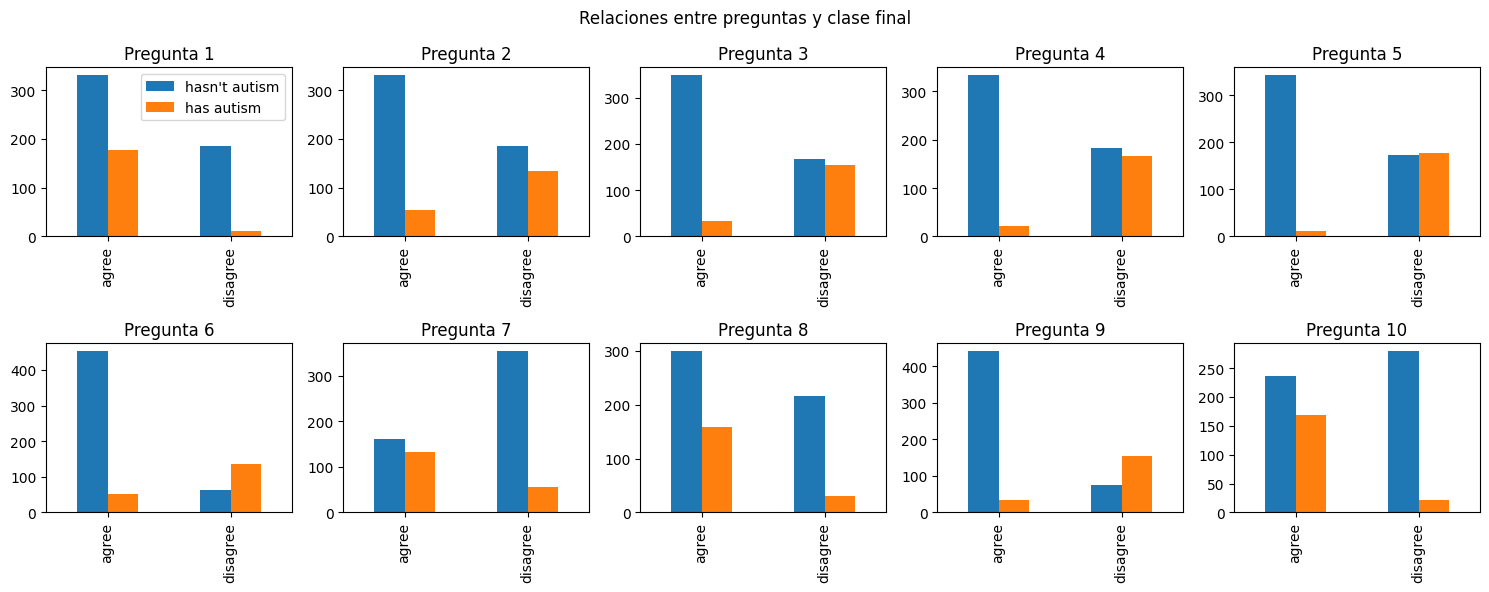

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    col = X.columns[i]
    dibujar_relacion_variable_entrada_con_salida(X, col, f"Pregunta {i+1}", legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las 10 preguntas con la variable de salida")                   
fig.tight_layout()
plt.show()

<div style="display: flex; justify-content: center;">

| # | Pregunta | Dirección |
|---|---|---|
| 1 | I often notice small sounds when others do not. | Agree → ↑ Autismo |
| 2 | I usually concentrate more on the whole picture, rather than the small details. | Agree → ↓ Autismo |
| 3 | I find it easy to do more than one thing at once. | Agree → ↓ Autismo |
| 4 | If there is an interruption, I can switch back to what I was doing very quickly. | Agree → ↓ Autismo |
| 5 | I find it easy to read between the lines when someone is talking to me. | Agree → ↓ Autismo |
| 6 | I know how to tell if someone listening to me is getting bored. | Agree → ↓ Autismo |
| 7 | When I’m reading a story, I find it difficult to work out the characters’ intentions. | Agree → ↑ Autismo |
| 8 | I like to collect information about categories of things. | Agree → ↑ Autismo |
| 9 | I find it easy to work out what someone is thinking or feeling just by looking at their face. | Agree → ↓ Autismo |
| 10 | I find it difficult to work out people’s intentions. | Agree → ↑ Autismo |

</div>

### Relación de las variables binarias con la variable de salida

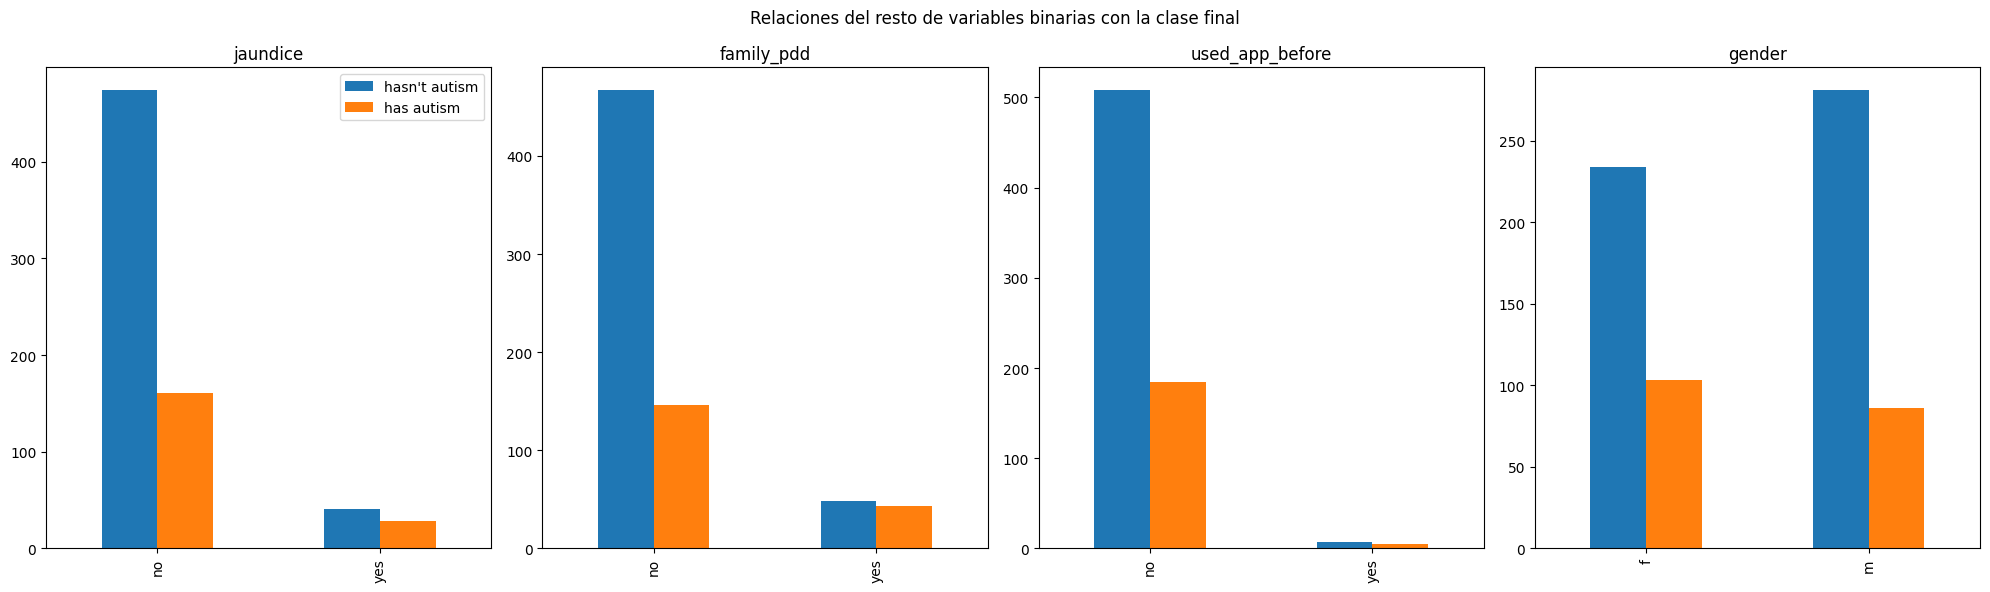

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.ravel()

cols = ["jaundice", "family_pdd", "used_app_before", "gender"]
for i, col in enumerate(cols):
    dibujar_relacion_variable_entrada_con_salida(X, col, col, legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las variables binarias con la variable de salida")
fig.tight_layout()
plt.show()

<div style="display: flex; justify-content: center;">

| Caracteristica | Dirección |
|---|---|
| Jaundice (Ictericia) | yes → ↑ Autismo |
| Family pdd | yes → ↑ Autismo |
| Used app before | yes → ↑ Autismo |
| Gender | m → ↓ Autismo |

</div>

### Relación de las variables restantes con la variable de salida

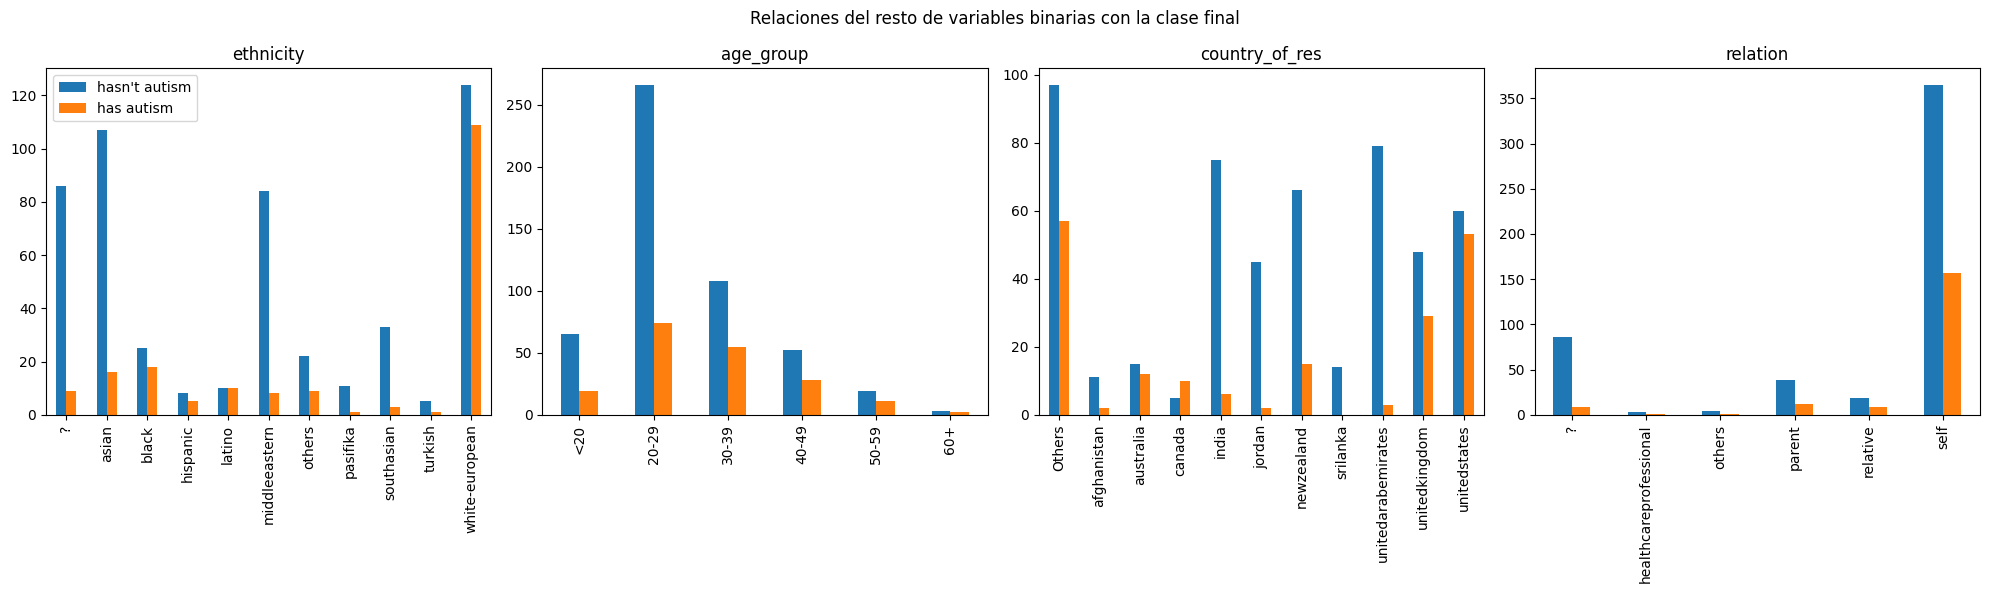

In [ ]:
# Formateamos resultados
Xaux = X.copy()
bins = [0, 19, 29, 39, 49, 59, 1000] 
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
Xaux["age_group"] = pd.cut(Xaux["age"], bins=bins, labels=labels)

top_countries = Xaux["country_of_res"].value_counts().nlargest(10).index
Xaux["country_of_res"] = Xaux["country_of_res"].apply(lambda x: x if x in top_countries else "Others")

# Mostramos los graficos
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes = axes.ravel()

cols = ["ethnicity", "age_group", "country_of_res", "relation"]
for i, col in enumerate(cols):
    dibujar_relacion_variable_entrada_con_salida(Xaux, col, col, legend=(i == 0), ax=axes[i])
            
fig.suptitle("Relación de las variables restantes con la variable de salida")
fig.tight_layout()
plt.show()

Nota: En la etnia, pais de residencia y relacion hay pocos datos de cada categoria, por lo que los resultados pueden ser engañosos.

* Ethnicity:
    * ↑ Autismo: black, hispanic, latino, white-european.
    * ↓ Autismo: middleeastem, pasifika, southasian, turkish.

* Age group:
    * ↑ Autismo: De 30 hacia arriba.
    * ↓ Autismo: De 30 hacia abajo.

* Country of residence (Mostramos los 10 paises con más datos):
    * ↑ Autismo: australia, canada, unitedkingdom, unitedstates
    * ↓ Autismo: afghanistan, india, jordan, newzealand, srilanka, unitedarabemirates

* Relation: No aporta demasiada información, en la siguiente celda la eliminamos.

In [66]:
X = X.drop(columns=["relation"])

<a id="pipeline"></a>
# 2. Pipeline

<a id="componentes"></a>
## 2.1 Componentes

La solución se organiza mediante un `Pipeline`, de forma que los tratamientos de datos y el clasificador se ejecuten siempre en el mismo orden y sin fuga de información entre entrenamiento y validación.

Los componentes principales son:

- **Imputer**: trata los valores perdidos en variables numéricas y categóricas.
- **Transformador**: convierte variables categóricas a una representación numérica.
- **Basico**: paso mínimo para que KNN pueda ejecutarse incluso cuando algunos tratamientos están desactivados.
- **OutlierDetector**: detecta y reemplaza valores atípicos.
- **Estandarizador**: escala las variables numéricas para mejorar el comportamiento de KNN.
- **KNeighborsClassifier**: modelo base utilizado para la clasificación.

In [67]:
# =====================================================================
# Particion train/val/test estratificada (60% / 20% / 20%)
# =====================================================================
X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size=0.25, random_state=seed, stratify=y_resto)

# Pasamos las clases "no"/"yes" a 0/1
y_train = y_train.map({'no': 0, 'yes': 1})
y_val = y_val.map({'no': 0, 'yes': 1})
y_test = y_test.map({'no': 0, 'yes': 1})


# =====================================================================
# Clase "Basico": el minimo para que KNN funcione
# ---------------------------------------------------------------------
# Si los demas tratamientos (Imputer, Transformador) NO estan activos:
#   - codifica categoricas a numero
#   - rellena NaN numericos con la mediana
# Si SI estan activos, no hace nada (los datos ya llegan limpios).
# =====================================================================
class Basico(TransformerMixin, BaseEstimator):

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        # Aprendemos: la lista de categorias de cada columna categorica
        # y la mediana de cada columna numerica.
        self.categorias = {}
        self.medianas = {}

        for col in X.columns:
            if X[col].dtype.name == 'category':
                self.categorias[col] = list(X[col].cat.categories)
            else:
                self.medianas[col] = X[col].median()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        # 1) Categoricas -> numero (NaN se convierte en -1)
        for col in self.categorias:
            categorias = self.categorias[col]
            X[col] = pd.Categorical(X[col], categories=categorias).codes

        # 2) NaN numericos -> mediana del train
        for col in self.medianas:
            if col in X.columns:
                X[col] = X[col].fillna(self.medianas[col])

        return X


# =====================================================================
# Funcion que construye un Pipeline segun que tratamientos esten activos
# =====================================================================
def construir_pipeline(usar_imputador, usar_transformador, usar_outlier, usar_estandarizador):
    pasos = []

    if usar_imputador:
        pasos.append(('imputador', Imputer()))

    if usar_transformador:
        pasos.append(('transformador', Transformador()))

    # El paso "basico" va siempre, este o no este el resto
    pasos.append(('basico', Basico()))

    if usar_outlier:
        pasos.append(('outlier', OutlierDetector()))

    if usar_estandarizador:
        pasos.append(('estandarizador', StandardScaler()))

    pasos.append(('clasificador', KNeighborsClassifier()))

    return Pipeline(pasos)


# =====================================================================
# Funcion que mide AUC-PR y F1 con validacion cruzada de 10 folds
# =====================================================================
def medir_metricas(pipeline, X, y):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    auc_pr_por_fold = cross_val_score(pipeline, X, y, cv=cv, scoring='average_precision', n_jobs=-1)
    f1_por_fold = cross_val_score(pipeline, X, y, cv=cv, scoring='f1', n_jobs=-1)

    auc_pr = auc_pr_por_fold.mean()
    f1 = f1_por_fold.mean()

    return auc_pr, f1

<a id="metricas"></a>
## 2.2 Métricas de validación y evaluación

### Método de validación


Usamos un enfoque de **Pipeline + GridSearchCV** porque este dataset tiene alrededor de **700 instancias**, un tamaño intermedio en el que podemos permitirnos validación cruzada sin que el coste computacional sea excesivo.

**Por qué Pipeline:**
- Encadena en un solo objeto todos los pasos de preprocesado y modelado (detección de outliers, escalado y clasificador).
- Garantiza que cada transformación se ajusta solo con los datos de entrenamiento de cada fold, evitando fuga de información.
- Hace el flujo reproducible y más fácil de mantener.

**Por qué GridSearchCV:**
- Permite buscar sistemáticamente la mejor combinación de hiperparámetros del KNN (`n_neighbors`, `weights`, `p`).
- En un conjunto de ~700 filas, una búsqueda en malla con validación cruzada de 5 folds sigue siendo viable.
- Devuelve el mejor modelo ya reentrenado y métricas por combinación para comparar decisiones.
- Como no tiene tantos hiperparametros es viable usar GridSearchCV en vez de RandomSearch.

**Tenemos varios métodos de validación posibles:**
- Hold Out (estratificación y repetición)
- K-Fold (estratificación)
- Leave-One-Out

**Por qué StratifiedKFold:**
- En este problema de clasificación, la variable objetivo puede estar desbalanceada.
- `StratifiedKFold` mantiene la proporción de clases en cada fold, reduciendo varianza en la estimación y haciendo la evaluación más estable que un KFold simple.


### Método de evaluación

Tenemos varios métodos de evaluación posibles:
- Dependientes del umbral:
    - Accuracy
    - F1-score

- Independientes del umbral:
    - AUC de la curva ROC
    - AUC de la curva Precisión-Recall

Para las medidas dependientes del umbral el accuracy es una medida bastante mala para datasets con desbalanceo
de clases porque no representa bien lo bueno que es el modelo en cada una de ellas, sino que lo hace de
manera general, por lo que si hay una clase que predomina bastante más frente a otra, el modelo puede ser muy bueno
en la clase mayoritaria y muy malo en clase minoritaria, y sin embargo, el accuracy saldría bastante alto. Por todo
lo anterior, usaremos el F1-score, ya que tiene en cuenta el recall y la precisión por clase, así que es inmune al
desbalanceo de clases, al mismo tiempo, cuando la precisión o el recall disminuyen penaliza bastante más que una simple
media por que hace la media geométrica entre la precisión y recall, pensando en nuestro problema en concreto, no tratamos con
falsos negativos delicados, como en el caso de un cancer, por lo que la prioridad es corregir lo mejor posible la clase
positiva y distinguir lo mejor posible la clase negativa.

Para las medidas independientes del umbral elegimos la **AUC de la curva Precisión-Recall**
en vez de la AUC de la curva ROC. La razón es de coherencia con la métrica dependiente del umbral: el F1-score se
calcula sobre la precisión y el recall de la clase positiva (autismo), y la curva Precisión-Recall mide exactamente
ese mismo trade-off a lo largo de todos los umbrales posibles. La curva ROC, en cambio, mezcla el comportamiento
sobre las dos clases (TPR vs FPR) y tiende a ser optimista cuando hay desbalance porque la clase mayoritaria
"infla" el FPR. Aunque nuestro desbalance es moderado (≈27/73), nos interesa más detectar bien los casos positivos
que distinguir bien los negativos, así que tanto F1-score como AUC-PR apuntan al mismo objetivo y son comparables
entre sí.

<a id="experimentos"></a>
# 3. Experimentos

En esta sección se comparan las combinaciones posibles de tratamientos para estudiar qué aporta cada componente al rendimiento del modelo. El objetivo no es solo obtener el mejor resultado, sino entender cómo interactúan los pasos del pipeline.

<a id="modelo_base"></a>
## 3.1 Análisis del modelo base

### Evaluación de todas las combinaciones de tratamientos

Para entender que aporta cada tratamiento (`Imputer`, `Transformador`, `OutlierDetector`,
`Estandarizador`) y como interactuan entre si, evaluamos **las 16 combinaciones posibles** de
encender/apagar cada uno. Asi vemos no solo si un tratamiento funciona por si solo, sino tambien
si **necesita a otro** para rendir mejor.

### Sobre el "baseline solo KNN"

KNN no admite NaN ni texto, asi que un baseline literal con **solo el clasificador** no es
ejecutable sobre estos datos. Para que **todas** las combinaciones puedan correr hemos añadido
un paso fijo (`Basico`) que:

- Codifica cualquier categorica que le llegue con `.cat.codes` (NaN → -1).
- Rellena NaN numericos con la mediana aprendida en train.

**No es un tratamiento real**, es solo el plumbing minimo. Cuando nuestros `Imputer` y
`Transformador` estan activos, el paso `Basico` no hace nada (los datos ya llegan limpios). Solo
entra en juego cuando los apagamos, para que el pipeline siga siendo ejecutable.

Con esto, **"baseline" = `Basico → KNN`** (la version mas tonta que corre), y vamos sumando
los 4 tratamientos en todas las combinaciones para leer el ranking.

In [ ]:
# =====================================================================
# Probamos las 16 combinaciones de tratamientos (2 * 2 * 2 * 2)
# Cada tratamiento puede estar ACTIVO (True) o INACTIVO (False).
# =====================================================================

resultados = []

for usar_imputador in [False, True]:
    for usar_transformador in [False, True]:
        for usar_outlier in [False, True]:
            for usar_estandarizador in [False, True]:

                # 1) Construimos el pipeline con esta combinacion
                pipeline = construir_pipeline(
                    usar_imputador,
                    usar_transformador,
                    usar_outlier,
                    usar_estandarizador
                )

                # 2) Medimos AUC-PR y F1 por validacion cruzada
                auc_pr, f1 = medir_metricas(pipeline, X_train, y_train)

                # 3) Construimos un nombre legible: "baseline + imputador + outlier", etc.
                activos = []
                if usar_imputador:
                    activos.append('imputador')
                if usar_transformador:
                    activos.append('transformador')
                if usar_outlier:
                    activos.append('outlier')
                if usar_estandarizador:
                    activos.append('estandarizador')

                if len(activos) == 0:
                    nombre = 'baseline'
                else:
                    nombre = 'baseline + ' + ' + '.join(activos)

                # 4) Componentes reales del pipeline (los nombres de los pasos)
                componentes = []
                for nombre_paso, paso in pipeline.steps:
                    componentes.append(nombre_paso)
                componentes = ' | '.join(componentes)

                # 5) Guardamos la fila en la lista de resultados
                fila = {
                    'combinacion': nombre,
                    'componentes': componentes,
                    'AUC_PR': round(auc_pr, 4),
                    'F1': round(f1, 4)
                }
                resultados.append(fila)


# Convertimos los resultados a una tabla y la ordenamos por AUC-PR
tabla = pd.DataFrame(resultados)
tabla = tabla.sort_values('AUC_PR', ascending=False)
tabla = tabla.reset_index(drop=True)

# Configuramos pandas para que no corte las columnas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

# Imprimimos la tabla completa
print(tabla.to_string(index=False))

# Imprimimos cual es la mejor combinacion
mejor = tabla.iloc[0]
print()
print('Mejor combinacion con valores por defecto:', mejor['combinacion'])
print('Componentes:', mejor['componentes'])
print('AUC-PR:', mejor['AUC_PR'])
print('F1:', mejor['F1'])

<a id="outliers"></a>
## 3.2 Análisis del componente DetectorOutlier

El componente `OutlierDetector` se analiza dentro de la tabla de combinaciones anterior, comparando las filas con y sin `outlier`.

La comparación permite observar que la detección de outliers no debe evaluarse de forma aislada. En algunos casos, al combinarse con transformación y estandarización, mejora la AUC-PR; en otros, puede no aportar tanto si el resto del pipeline no prepara correctamente las variables. Por eso se mantiene dentro de la búsqueda global y se afina posteriormente con `GridSearchCV`.

<a id="estandarizador"></a>
## 3.3 Análisis del componente Estandarizador

El componente `Estandarizador` es especialmente relevante porque el modelo utilizado es KNN. Como KNN se basa en distancias, las variables con escalas distintas pueden dominar el cálculo de vecinos si no se normalizan correctamente.

En la evaluación de combinaciones se observa que las variantes con estandarización se sitúan entre las mejores. Por ello, en la búsqueda final se comparan varias alternativas: `StandardScaler`, `RobustScaler`, `MinMaxScaler` y `passthrough`, dejando que `GridSearchCV` seleccione la opción más adecuada.

<a id="modelo"></a>
## 3.4 Análisis del componente Modelo

<a id="mejor_pipeline"></a>
## 3.5 Mejor pipeline

### Justificación de la combinación elegida

El ranking anterior recoge **todas** las combinaciones posibles de los 4 tratamientos, asi que la
mejor fila no es un optimo greedy: es el optimo real sobre la rejilla de tratamientos.

Como hemos probado las 16 combinaciones, podemos leer dos cosas en la tabla:

- **¿Aporta este tratamiento?** Compara `baseline` con `baseline + X`. Si la AUC-PR sube, X aporta
  por si solo.
- **¿Necesita compañia?** Si `baseline + X` no mejora, pero `baseline + X + Y` si lo hace mas que
  `baseline + Y` solo, entonces X solo rinde acompañado.

### El caso del imputador en nuestros datos

En la tabla anterior se ve que **añadir el imputador con sus defaults empeora ligeramente la
AUC-PR** respecto a tenerlo apagado:

```
baseline + transformador + outlier + estandarizador               -> 0.9446  (sin imputador)
baseline + imputador + transformador + outlier + estandarizador   -> 0.9317  (con imputador)
```

A primera vista parece que el imputador es un lastre. Pero la lectura correcta es otra:

- El `Imputer()` por defecto rellena `age` con la **mediana** y las categoricas con la string
  `"missed"`.
- El `Transformador()` por defecto usa `"orden"`, que asigna 0, 1, 2... por orden alfabetico de las
  categorias. Añadir la categoria `"missed"` desplaza la numeracion y mete ruido.
- En cambio, cuando el `Basico` esta solo (sin imputador), tambien rellena con la mediana y
  codifica los NaN categoricos como `-1`. Hacen casi lo mismo, asi que el imputador no aporta nada
  y la diferencia (0.013) cae dentro del ruido de la CV.

Cuando, en el siguiente paso, el `GridSearchCV` puede **tunear los metodos**, el imputador cambia
a `media` y el transformador a `conteo` (que codifica por frecuencia, no por orden alfabetico).
Ahi el imputador entra en la combinacion ganadora con **AUC-PR = 0.9690**.

**Conclusion**: el imputador no es malo, lo que es malo es la pareja `Imputer(mediana, missing) +
Transformador("orden")`. Por eso decir "este tratamiento no aporta" mirando solo la tabla de
combinaciones con defaults es engañoso: hay que dejar tambien al `GridSearchCV` ajustar los
metodos dentro de cada bloque. Es el ejemplo claro de que un tratamiento puede no rendir solo y
si rendir acompañado.

### Que hace el GridSearchCV combinado

Una vez fijada *que combinacion de bloques* usar, el siguiente `GridSearchCV` afina **los
metodos** dentro de cada bloque (`media` vs `mediana`, `iqr` vs `mediastd`, `StandardScaler` vs
`RobustScaler`, `orden` vs `conteo` vs `ohe` vs `binary`, etc.) sobre toda la rejilla. Es la
busqueda fina, no la decision estructural — y es la que sube de 0.9446 a 0.9690.

In [ ]:
# Busqueda combinada sobre todos los tratamientos a la vez

pipe = Pipeline([
    ('imputador', Imputer()),
    ('transformador', Transformador()),
    ('outlier', OutlierDetector()),
    ('estandarizador', StandardScaler()),
    ('clasificador', KNeighborsClassifier()),
])

param_grid = {
    "imputador__metodo_imputacion_vars_num": ["media", "mediana"],
    "imputador__metodo_imputacion_vars_cat": ["moda", "missing"],
    "transformador__metodo_cat_num": ["orden", "conteo", "ohe", "binary"],
    "estandarizador": [StandardScaler(), RobustScaler(), MinMaxScaler(), 'passthrough'], # passthrough evalúa dejar estandarizador en None
    "outlier__deteccion": ["iqr", "mediastd"],
    "outlier__reemplazo": ["mediana", "media", "min", "max", "moda"],
    # "modelo__n_neighbors": [1, 2, 3, 5, 8],                       # Dejar comentado hasta el final (antes de la entrega)
    # "modelo__weights": ["uniform", "distance"],                   # Dejar comentado hasta el final (antes de la entrega)
    # "modelo__p": [1, 2],                                          # Dejar comentado hasta el final (antes de la entrega)
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=seed), # n_splits = 10, dataset pequeño
    n_jobs=-1, # para usar todos los nucleos del cpu
    scoring="average_precision",   # AUC-PR, coherente con el F1 que usaremos para fijar el umbral
    return_train_score=True)

grid.fit(X_train, y_train)

for k, v in grid.best_params_.items():
    print(f"Entre {param_grid[k]}\nMejor {k}: {v}\n")
print(f"AUC-PR (CV) de la combinacion ganadora: {grid.best_score_:.4f}")

Entre [StandardScaler(), RobustScaler(), MinMaxScaler(), 'passthrough']
Mejor estandarizador: MinMaxScaler()

Entre ['moda', 'missing']
Mejor imputador__metodo_imputacion_vars_cat: missing

Entre ['media', 'mediana']
Mejor imputador__metodo_imputacion_vars_num: media

Entre ['iqr', 'mediastd']
Mejor outlier__deteccion: mediastd

Entre ['mediana', 'media', 'min', 'max', 'moda']
Mejor outlier__reemplazo: moda

Entre ['orden', 'conteo', 'ohe', 'binary']
Mejor transformador__metodo_cat_num: conteo

AUC-PR (CV) de la combinacion ganadora: 0.9690


### Ajuste del umbral de clasificación

Después de seleccionar la mejor combinación mediante AUC-PR, se ajusta el umbral de decisión usando el conjunto de validación. Esto permite optimizar el F1-score, que es la métrica dependiente del umbral elegida para evaluar el rendimiento final.

In [ ]:
def clasificacion_umbral(probs_clase_positiva, umbral=0.5):
    return np.where(probs_clase_positiva >= umbral, 1, 0)

def calcular_mejor_umbral_fscore(model, X_val, y_val, labels=['no', 'yes']):    
    model_probs_val = model.predict_proba(X_val)
    
    model_precision, model_recall, umbrales = precision_recall_curve(y_val, model_probs_val[:,1])
    
    rendimiento_umbrales = [f1_score(y_val, 
                                     clasificacion_umbral(model_probs_val[:,1], umbral=umbral)) 
                                for umbral in umbrales]
    indiceMejorUmbral = np.argmax(rendimiento_umbrales)

    mejorUmbral = umbrales[indiceMejorUmbral]
    print('Mejor umbral: {:.3f}\nFscore en validacion: {:.2f}'.format(mejorUmbral, rendimiento_umbrales[indiceMejorUmbral]))

    return mejorUmbral

umbral = calcular_mejor_umbral_fscore(grid, X_val, y_val.values)
print(f"F-Score en test: {f1_score(y_test, clasificacion_umbral(grid.predict_proba(X_test)[:,1], umbral))}")

Mejor umbral: 0.400
Fscore en validacion: 0.90
F-Score en test: 0.9487179487179487


<a id="interpretabilidad"></a>
# 4. Interpretación

<a id="conclusiones"></a>
# 5. Conclusiones

El trabajo muestra que el problema puede abordarse correctamente mediante una solución automatizada basada en `Pipeline`, validación cruzada estratificada y KNN.

A partir del análisis realizado, las principales conclusiones son:

- Las preguntas del cuestionario AQ-10 aportan información relevante, aunque no todas tienen la misma fuerza predictiva.
- Algunas variables externas, como `family_pdd`, también muestran relación clara con la variable objetivo.
- Variables como `ethnicity`, `country_of_res` o `gender` pueden discriminar dentro del dataset, pero deben interpretarse con cuidado porque pueden reflejar sesgos de muestreo.
- El uso de `Pipeline` evita fugas de información y permite comparar tratamientos de forma ordenada.
- La métrica principal independiente del umbral es **AUC-PR**, coherente con el uso posterior del **F1-score**.
- La mejor combinación por defecto fue `baseline + transformador + outlier + estandarizador`, con **AUC-PR = 0.9446** y **F1 = 0.8752**.
- Tras la búsqueda combinada con `GridSearchCV`, la mejor configuración alcanzó **AUC-PR = 0.9690** en validación cruzada.
- Ajustando el umbral de clasificación a **0.400**, el modelo obtuvo un **F1-score en test = 0.9487**.

En conclusión, el mejor modelo obtenido es una solución sólida para este dataset. Sin embargo, al tratarse de datos sensibles y con posibles sesgos de autoselección, el resultado debe entenderse como un predictor experimental sobre este conjunto de datos, no como una herramienta clínica definitiva.